# 02_分类算法-LightGBM

## Notebook 使用说明

建议先阅读理论，再从上到下运行全部单元；使用 Python 3.11–3.13 内核。数据与辅助模块均来自本文件夹，安装依赖后无需联网获取案例数据。

本篇数据：`dataset/house-prices-advanced-regression-techniques/test.csv`、`dataset/house-prices-advanced-regression-techniques/train.csv`。

转写调整：

- LightGBM 房价案例的缺失值处理移入 Pipeline，训练和预测共用训练集统计量。
- 修复或适配代码；原讲解性输出保留为 Markdown，Python 单元按顺序执行。
- 大规模参数网格缩为每维至多两个候选值；所有候选仍真实训练，未跳过运行。

原文件位于“分类算法”目录，但案例实际是房价回归；本篇保留原目录和回归案例，评估使用回归指标。

原文参考图及静态数值仅用于对照；重跑后的代码输出为本次实验结果。依赖版本与验证记录见根目录 `README.md` 和 `reports/`。

In [1]:
# 从当前目录向上寻找本套 Notebook 的根目录，移动整个文件夹后仍可运行。
from pathlib import Path
import os, sys, tempfile, random
ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / "notebook_support.py").is_file()), None)
if ROOT is None:
    raise FileNotFoundError("请从这套 Notebook 文件夹内启动 Jupyter，并保留 notebook_support.py。")
sys.path.insert(0, str(ROOT))
os.environ.setdefault("MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "ml_notebooks_matplotlib"))
from notebook_support import DATA_DIR, load_local_housing, load_local_boston, load_local_mnist, load_creditcard
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
random.seed(42)
np.random.seed(42)
# 按实际安装的字体选择，兼容 macOS / Windows / Linux。
_available_fonts = {f.name for f in font_manager.fontManager.ttflist}
CJK_FONTS = [f for f in ["Arial Unicode MS", "PingFang SC", "Heiti TC", "Microsoft YaHei", "SimHei", "Noto Sans CJK SC"]
             if f in _available_fonts] + ["DejaVu Sans"]
plt.rcParams.update({"font.sans-serif": CJK_FONTS, "axes.unicode_minus": False,
                     "figure.dpi": 90, "figure.max_open_warning": 30})
%matplotlib inline


本文咱们把LightGBM的一些细节和大家一起梳理一下\~

首先，LightGBM 适合处理大规模数据，能够快速、高效地提供高准确性的预测结果。

对于很多初学者来说，只需要知道它是一种可以帮助我们更好、更快地做预测的工具就可以了。

具体来说，LightGBM，全称为 Light Gradient Boosting Machine，它的名字里包含“Light”，意思是它运行起来非常“轻量级”，速度快、内存占用少。

我们可以把 LightGBM 想象成一位非常聪明的“数据分析师”，**它可以通过不断调整和改进自己的预测来提高准确性**。它是怎么做到的呢？它采用了一种叫做“梯度提升”的技术，这种技术会训练一系列的小模型（也叫“决策树”），每个模型都尝试修正前一个模型的错误，最终组合起来，形成一个强大的预测工具。

这里，咱们大概阐述一下关于LightGBM 的一些显著特点：

**1. 速度快**：相比于传统的梯度提升算法（比如 XGBoost），LightGBM 训练速度更快。因为它在数据和模型上进行了很多优化，比如使用直方图算法来加速计算。

**2. 内存效率高**：它占用的内存更少，能处理更大规模的数据集。

**3. 高精度**：由于它能利用复杂的模型结构，往往可以提供很高的预测准确性。

**4. 支持并行计算**：可以利用多核 CPU 或者 GPU 来加速训练过程。

**5. 自动处理缺失值**：不需要额外处理数据中的缺失值，LightGBM 会自动进行处理。

**6. 支持分类和回归任务**：不仅可以处理分类问题（比如预测邮件是不是垃圾邮件），也可以处理回归问题（比如预测房价）。

假如你在做预测一名学生考试成绩的模型。首先，你猜这个学生的分数是60分（基础模型）。然后你发现，学生的实际分数比你猜的高了或者低了。于是，你再根据误差调整一下你的预测，比如这次你根据多学了一些特征后，你猜他会得70分。

不断重复这个过程，每次都根据上一次的误差进行改进，最终你会得到一个非常接近实际成绩的预测。这就是梯度提升的基本思想，而 LightGBM 就是用这种方式来提高预测准确性的工具。

## 理论基础

核心：通过逐步建立决策树模型来优化预测结果，并在效率和准确性上进行了许多改进。

### 梯度提升的基本原理

梯度提升（Gradient Boosting）是一种迭代的提升算法，目的是通过逐步构建弱学习器（通常是决策树），并将这些弱学习器组合成一个强学习器来提高预测性能。

**1. 目标函数**

给定一个数据集 $\{(x_i, y_i)\}_{i=1}^N$，目标是找到一个函数 $F(x)$来最小化损失函数 $L(y, F(x))$。对于回归问题，常见的损失函数是均方误差：


$$
L(y, F(x)) = \frac{1}{N} \sum_{i=1}^N (y_i - F(x_i))^2
$$


**2. 模型表示**

梯度提升模型表示为：


$$
F(x) = \sum_{m=1}^M \beta_m h_m(x)
$$


其中，$h_m(x)$是第 $m$棵决策树，$\beta_m$是其对应的权重。

**3. 梯度提升的迭代过程**

梯度提升算法通过逐步构建新树来拟合前一模型的残差。

- 初始化模型：  
$F_0(x) = \arg \min_\beta \sum_{i=1}^N L(y_i, \beta)$
- 对于每个迭代 $m = 1, \ldots, M$：
- 计算当前模型的残差：  
$r_{i,m} = -\left[ \frac{\partial L(y_i, F(x_i))}{\partial F(x_i)} \right]_{F(x) = F_{m-1}(x)}$
- 拟合一棵新树 $h_m(x)$来预测残差 $r_{i,m}$。
- 更新模型：  
$F_m(x) = F_{m-1}(x) + \beta_m h_m(x)$  
其中，$\beta_m$是步长（学习率），可以通过线搜索确定。

### LightGBM 的改进

LightGBM 在传统的梯度提升算法基础上，进行了以下几方面的改进：

**1. 直方图算法（Histogram-based Algorithm）**：

LightGBM 使用直方图算法将连续特征离散化为 k 个桶，从而减少了计算量。构建直方图的步骤：

- 将每个特征的取值划分为 k 个离散区间（桶）。
- 统计每个区间内的样本数量和梯度的总和。
- 使用直方图加速计算最佳分割点。

**2. 基于叶子的最佳分割（Leaf-wise Growth）**：

传统的梯度提升算法使用层级生长（Level-wise Growth）策略，即在每一层同时分裂所有叶子节点。LightGBM 则使用基于叶子的生长策略，每次分裂当前损失最大的叶子节点，这样可以更快地减少误差。

**3. 缺失值处理**：

LightGBM 自动处理缺失值，将缺失值单独作为一个类别，并在训练过程中自动选择最佳分裂方向。

**4. 数据并行和特征并行**：

LightGBM 支持数据并行和特征并行，通过分布式计算加速模型训练。

### 数学推导

LightGBM 的核心是使用决策树拟合残差，并通过梯度提升进行优化。以下是详细的公式推导过程：

**1. 初始化模型**：


$$
F_0(x) = \arg \min_\beta \sum_{i=1}^N L(y_i, \beta)
$$


**2. 计算残差**：

在第 $m$次迭代中，计算当前模型的残差：


$$
r_{i,m} = -\left[ \frac{\partial L(y_i, F(x_i))}{\partial F(x_i)} \right]_{F(x) = F_{m-1}(x)}
$$


对于均方误差损失函数，残差为：  
$r_{i,m} = y_i - F_{m-1}(x_i)$

**3. 构建直方图**：

将每个特征的取值离散化为 k 个桶，统计每个桶的样本数量和梯度的总和。

**4. 寻找最佳分割点**：

对每个桶，计算分割点的增益，增益公式为：


$$
\text{Gain} = \frac{1}{2} \left( \frac{G_L^2}{H_L + \lambda} + \frac{G_R^2}{H_R + \lambda} - \frac{(G_L + G_R)^2}{H_L + H_R + \lambda} \right) - \gamma
$$


其中，$G_L$和 $G_R$分别是左子树和右子树的梯度和，$H_L$和 $H_R$分别是左子树和右子树的二阶梯度和，$\lambda$是正则化参数，$\gamma$是叶节点数目的惩罚项。

**5. 更新模型**：

使用找到的最佳分割点分裂节点，并更新模型：


$$
F_m(x) = F_{m-1}(x) + \beta_m h_m(x)
$$


其中，$\beta_m$是步长（学习率）。

### 算法流程

**1. 数据预处理**：

- 将连续特征离散化为 k 个桶。
- 处理缺失值，将缺失值单独作为一个类别。

**2. 初始化模型**：

- 初始化常数模型 $F_0(x)$。

**3. 迭代训练**：

- 对每次迭代 $m$：

  - 计算当前模型的残差 $r_{i,m}$。
  - 构建直方图，加速寻找最佳分割点。
  - 使用基于叶子的生长策略，选择当前损失最大的叶子节点进行分裂。
  - 更新模型 $F_m(x)$。

**4. 输出模型**：

- 训练完成后，输出最终的预测模型 $F_M(x)$。

总的来说，LightGBM 通过对传统梯度提升算法的改进，显著提高了训练速度和模型性能，特别适合处理大规模数据集。它的直方图算法、基于叶子的生长策略和并行计算能力，使得它在实践中表现非常出色。

## 完整案例

我们现在给大家一个实际的例子，用 LightGBM 进行房价预测。

数据集：使用Kaggle 上的 "House Prices: Advanced Regression Techniques"

也可以在，公众号「深夜努力写Python」后台回复『数据集』获取\~

**导入库 & 加载数据**

In [2]:
import lightgbm as lgb
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt
import seaborn as sns

# 加载数据
train = pd.read_csv(DATA_DIR / 'house-prices-advanced-regression-techniques/train.csv')
test = pd.read_csv(DATA_DIR / 'house-prices-advanced-regression-techniques/test.csv')

# 查看数据结构
print(train.head())
print(train.info())

   Id  MSSubClass MSZoning  LotFrontage  LotArea Street Alley LotShape  \
0   1          60       RL         65.0     8450   Pave   NaN      Reg   
1   2          20       RL         80.0     9600   Pave   NaN      Reg   
2   3          60       RL         68.0    11250   Pave   NaN      IR1   
3   4          70       RL         60.0     9550   Pave   NaN      IR1   
4   5          60       RL         84.0    14260   Pave   NaN      IR1   

  LandContour Utilities  ... PoolArea PoolQC Fence MiscFeature MiscVal MoSold  \
0         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
1         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      5   
2         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      9   
3         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
4         Lvl    AllPub  ...        0    NaN   NaN         NaN       0     12   

  YrSold  SaleType  SaleCondition  SalePrice  
0   2008        WD   

**数据预处理与特征工程**

In [3]:
# 分离特征和目标
X = train.drop(['Id', 'SalePrice'], axis=1)
y = train['SalePrice']
X_test = test.drop('Id', axis=1)

# 将数值型和分类型特征分开
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns
categorical_features = X.select_dtypes(include=['object']).columns

# 缺失值填补与编码都在 Pipeline 内拟合。
from sklearn.impute import SimpleImputer
# 预处理数值型特征和分类型特征
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

# 将预处理步骤和模型结合起来
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', lgb.LGBMRegressor(n_jobs=1, verbosity=-1))
])

**拆分训练集和验证集**

In [4]:
# 拆分训练集和验证集
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

**进行模型训练和评估**

In [5]:
# 训练模型
pipeline.fit(X_train, y_train)

# 预测验证集
y_pred = pipeline.predict(X_val)

# 评估模型
rmse = np.sqrt(mean_squared_error(y_val, y_pred))
r2 = r2_score(y_val, y_pred)

print(f'RMSE: {rmse}')
print(f'R^2: {r2}')

RMSE: 29531.3408555632
R^2: 0.8863020855735843


**超参数优化**

In [6]:
# 定义参数网格
param_grid = {
    'regressor__num_leaves': [31, 61],
    'regressor__learning_rate': [0.05, 0.1],
    'regressor__n_estimators': [100, 200]
}

# 网格搜索
grid_search = GridSearchCV(pipeline, param_grid, cv=5, scoring='neg_mean_squared_error', verbose=1, n_jobs=1, error_score='raise')
grid_search.fit(X_train, y_train)

# 最佳参数
print("Best parameters found: ", grid_search.best_params_)

# 使用最佳参数进行预测
y_pred_best = grid_search.predict(X_val)

# 评估
rmse_best = np.sqrt(mean_squared_error(y_val, y_pred_best))
r2_best = r2_score(y_val, y_pred_best)

print(f'Optimized RMSE: {rmse_best}')
print(f'Optimized R^2: {r2_best}')

Fitting 5 folds for each of 8 candidates, totalling 40 fits


Best parameters found:  {'regressor__learning_rate': 0.05, 'regressor__n_estimators': 100, 'regressor__num_leaves': 31}
Optimized RMSE: 30408.845084460936
Optimized R^2: 0.8794447805225939


**预测测试集并导出结果**

In [7]:
# 使用最佳模型预测测试集
y_test_pred = grid_search.predict(X_test)

# 导出预测结果
output = pd.DataFrame({'Id': test.Id, 'SalePrice': y_test_pred})
output.to_csv(ROOT / 'reports' / 'lightgbm_submission.csv', index=False)
print("Submission file created.")

Submission file created.


**可视化分析**

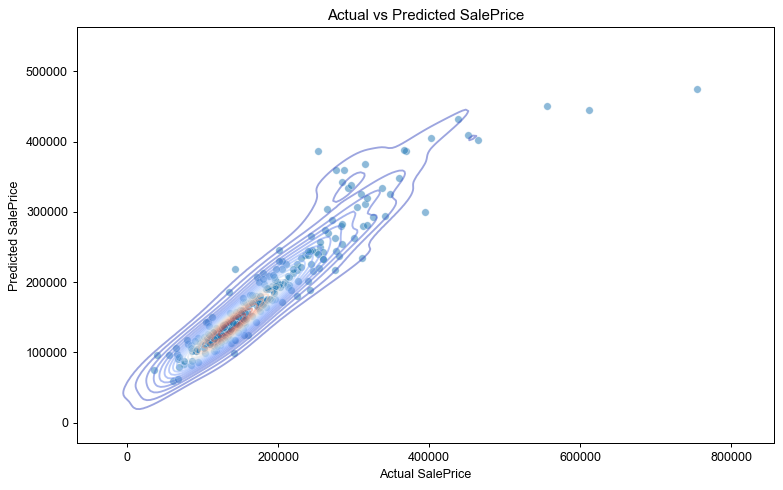

In [8]:
# 预测与实际值对比图
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_val, y=y_pred_best, alpha=0.5)
sns.kdeplot(x=y_val, y=y_pred_best, cmap='coolwarm', alpha=0.5, levels=20)
plt.xlabel("Actual SalePrice")
plt.ylabel("Predicted SalePrice")
plt.title("Actual vs Predicted SalePrice")
plt.show()

![原文参考图，当前结果见代码输出](attachments/img_027.png)

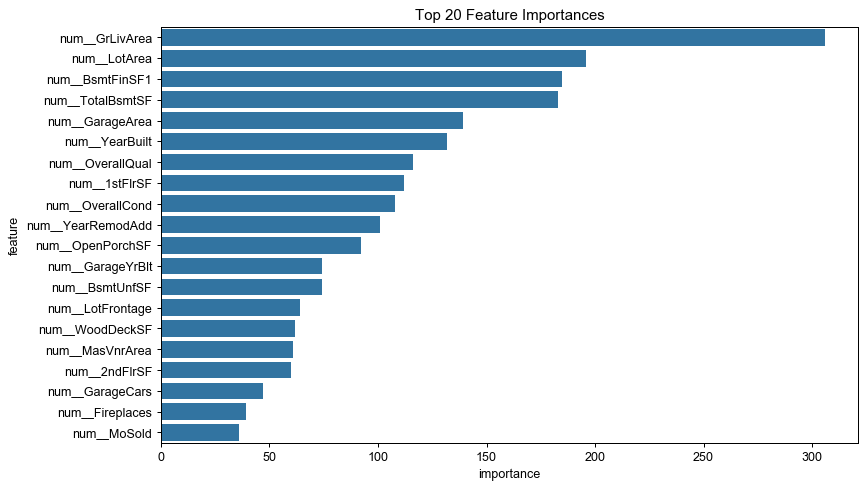

In [9]:
# 特征重要性
feature_importances = grid_search.best_estimator_.named_steps["regressor"].feature_importances_
feature_names = grid_search.best_estimator_.named_steps["preprocessor"].get_feature_names_out()
feature_importances_df = pd.DataFrame({'feature': feature_names, 'importance': feature_importances})
feature_importances_df = feature_importances_df.sort_values('importance', ascending=False).head(20)

plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importances_df, x='importance', y='feature')
plt.title('Top 20 Feature Importances')
plt.show()

![原文参考图，当前结果见代码输出](attachments/img_028.png)

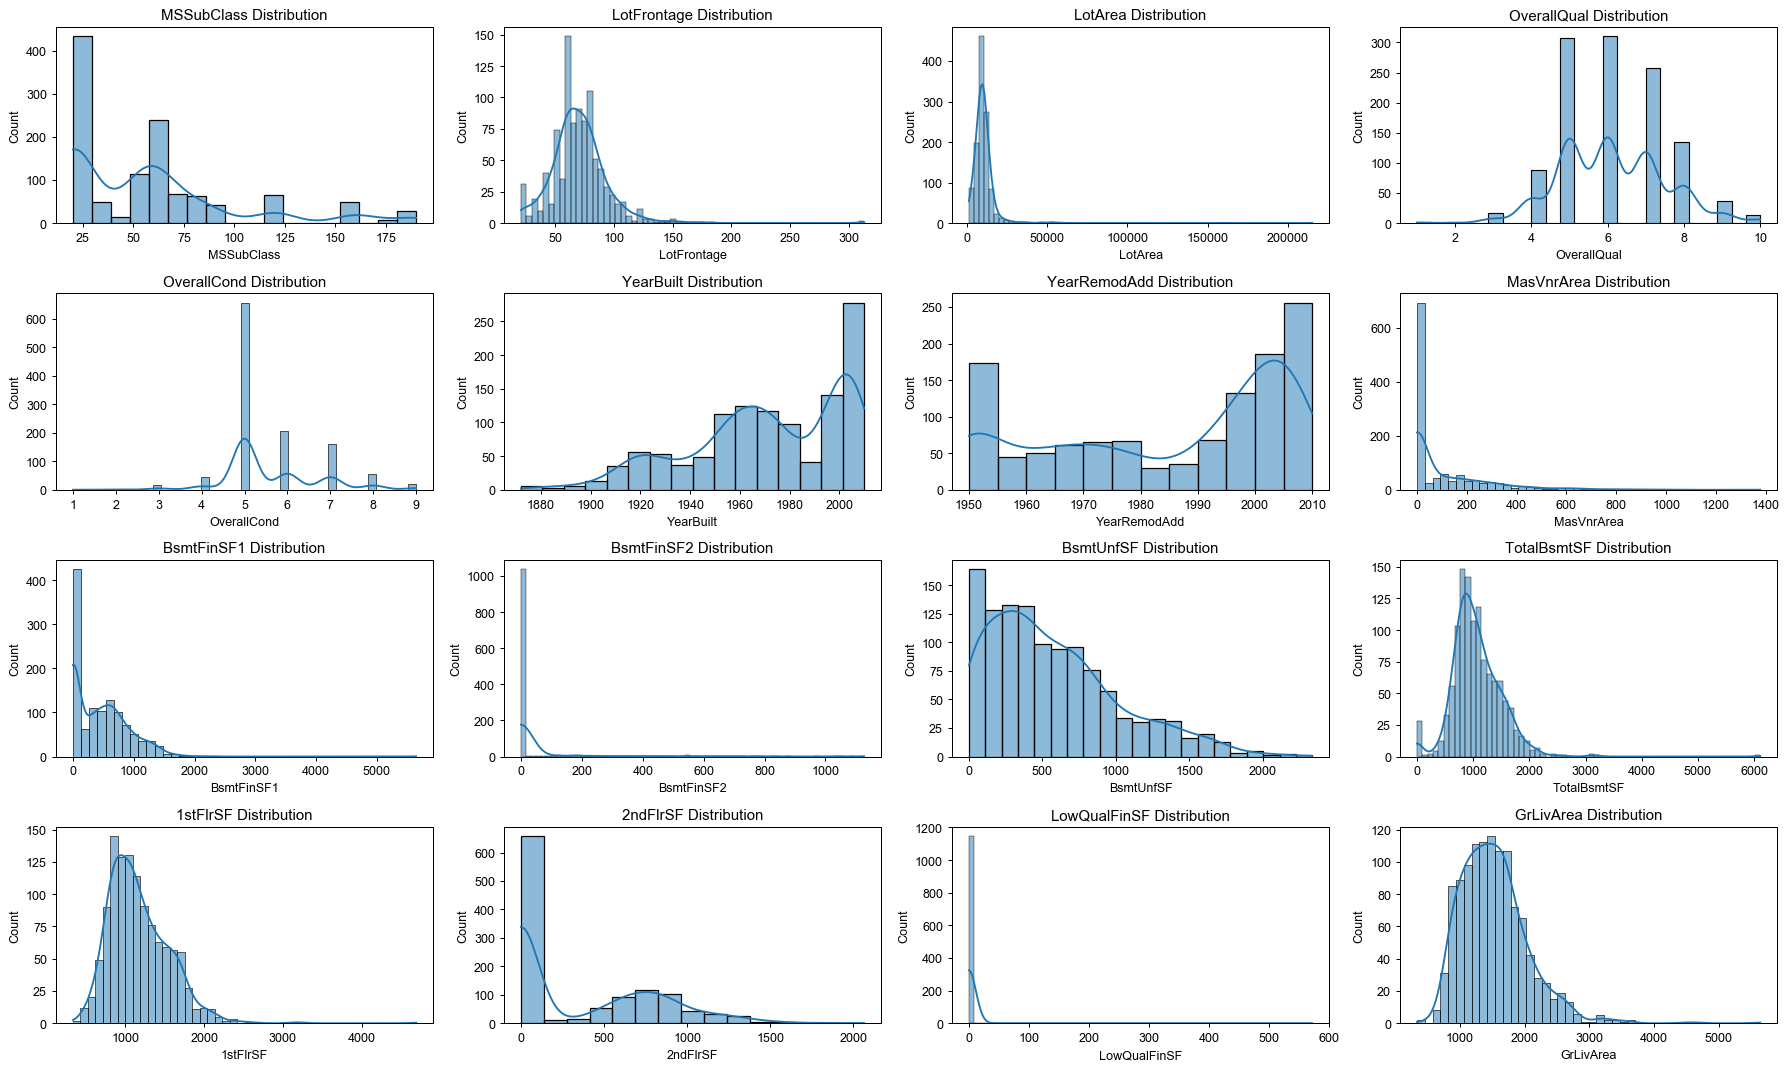

In [10]:
# 特征分布可视化
def visualize_distribution(data, features):
    plt.figure(figsize=(20, 12))
    for i, feature in enumerate(features):
        plt.subplot(4, 4, i+1)
        sns.histplot(data[feature], kde=True)
        plt.title(f'{feature} Distribution')
    plt.tight_layout()
    plt.show()

# 查看数值型特征的分布
numeric_features_sample = numeric_features[:16]  # 取前16个数值型特征进行可视化
visualize_distribution(X_train, numeric_features_sample)

![原文参考图，当前结果见代码输出](attachments/img_029.png)

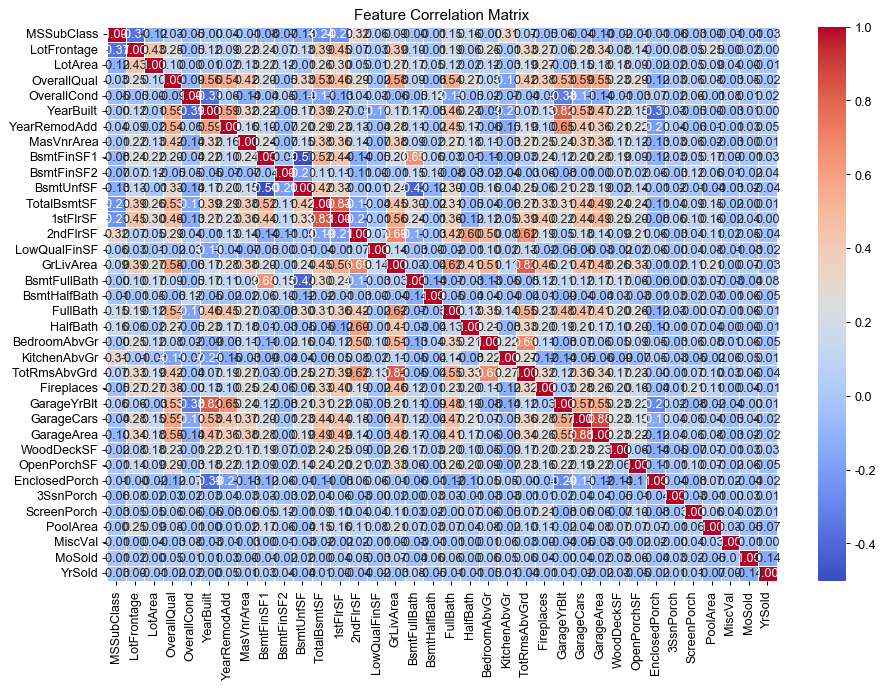

In [11]:
# 特征相关性矩阵可视化
def visualize_correlation(data, features):
    correlation_matrix = data[features].corr()
    plt.figure(figsize=(12, 8))
    sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
    plt.title("Feature Correlation Matrix")
    plt.show()

# 查看特征相关性
visualize_correlation(X_train, numeric_features)

![原文参考图，当前结果见代码输出](attachments/img_030.png)

整个代码，包括了详细的数据预处理、特征工程、模型训练、超参数优化和可视化分析，而且适用于更复杂的数据集。大家可以通过代码的细节和注释，进行学习和理解\~

## 模型分析

咱们先聊一下 LightGBM 的优缺点，后面再聊聊 LightGBM 和其他算法的对比！\~

**LightGBM的优点**

**1. 高效性**：LightGBM的训练速度快，适用于处理大规模数据。

**2. 准确性**：LightGBM在预测准确性方面通常表现良好。

**3. 低内存占用**：LightGBM在内存占用方面相对较低，能够处理大规模数据而不会导致内存溢出问题。

**4. 自动处理缺失值**：LightGBM能够自动处理缺失值，简化了数据预处理的流程。

**LightGBM的缺点**

**1. 容易过拟合**：与其他树模型类似，LightGBM容易过拟合，需要进行适当的正则化。

**2. 对超参数敏感**：LightGBM的性能受超参数的影响较大，需要进行仔细调参。

**3. 不适用于小样本数据**：LightGBM在小样本数据上可能表现不佳，需要足够的数据量才能发挥其优势。

**与相似算法的对比**

| **对比项** | **LightGBM vs. XGBoost** | **LightGBM vs. Random Forest** | **LightGBM vs. CatBoost** |
|-|-|-|-|
| **训练速度** | LightGBM 训练速度更快，尤其在大规模数据上 | LightGBM 训练通常比随机森林快 | LightGBM 训练速度快于 CatBoost |
| **数据规模** | 适合大规模数据，XGBoost 在小样本数据集上可能更稳定 | LightGBM 适合大规模数据，随机森林在中小规模数据上仍有竞争力 | LightGBM 和 CatBoost 都适合大规模数据 |
| **精度表现** | XGBoost 在某些小样本数据集上可能更精确 | LightGBM 通常比随机森林精度高 | CatBoost 可能在类别型特征较多的数据集上表现更好 |
| **特征处理** | 对类别型特征需要预处理 | 随机森林能处理类别型特征但表现一般 | CatBoost 处理类别型特征更自然，无需独热编码 |
| **超参数调优** | 超参数较多，调优复杂 | 随机森林相对易调优 | CatBoost 超参数较少，相对易调优 |
| **缺失值处理** | 自动处理缺失值 | 可能对缺失值敏感，需要填充 | CatBoost 处理缺失值能力较强 |
| **计算资源** | 需要较大计算资源，但比 XGBoost 更高效 | 随机森林计算成本较低，但预测时计算量较大 | 计算成本与 LightGBM 相当，但训练时更稳定 |
| **适用场景** | 适用于大规模数据，要求高性能的任务 | 适用于对解释性要求较高的任务，如特征重要性分析 | 适用于类别型特征较多的任务，如推荐系统、金融风控 |

希望可以帮助大家再实际项目或者实验中进行选择。